# Crypto Forecasting — Time Series Forecasting

**Goal:** Forecast cryptocurrency prices using the latest available market data when this notebook is run.

This notebook uses **Bitcoin (BTC-USD)** by default and can be changed to another Yahoo Finance crypto ticker such as `ETH-USD`, `SOL-USD`, or `BNB-USD`.

### Models included
- Naive baseline
- ARIMA
- Prophet
- LSTM
- Random Forest regression with lag/technical features

### Important
Crypto markets are highly volatile. Forecasts are statistical estimates for educational/research purposes and are **not financial advice**.

The notebook downloads fresh historical data at execution time using `yfinance`, whose current API supports cryptocurrency tickers and historical intervals. 


In [1]:
# Install dependencies (run once)
%pip install -q yfinance pandas numpy matplotlib seaborn scikit-learn statsmodels prophet tensorflow ta

Note: you may need to restart the kernel to use updated packages.


In [2]:
# Imports
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf

from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import MinMaxScaler

from statsmodels.tsa.arima.model import ARIMA

from prophet import Prophet

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

print("TensorFlow:", tf.__version__)
print("yfinance:", yf.__version__)


Importing plotly failed. Interactive plots will not work.


TensorFlow: 2.21.0
yfinance: 1.7.0


## 1. Configuration

Change `TICKER` to forecast another cryptocurrency.

Examples:
- `BTC-USD` — Bitcoin
- `ETH-USD` — Ethereum
- `SOL-USD` — Solana
- `BNB-USD` — BNB


In [3]:
# Configuration
TICKER = "BTC-USD"

# Maximum historical period available through the selected source
PERIOD = "max"

# Forecast horizon
FORECAST_DAYS = 30

# Test set size
TEST_SIZE = 60

# LSTM sequence length
LOOKBACK = 60

print("Selected asset:", TICKER)


Selected asset: BTC-USD


## 2. Download the latest historical data

The data is fetched when this cell runs, so the notebook does not depend on a fixed CSV downloaded today.


In [4]:
# Download fresh historical data
data = yf.download(
    TICKER,
    period=PERIOD,
    interval="1d",
    auto_adjust=True,
    progress=False
)

if data.empty:
    raise ValueError("No data was returned. Check the ticker or internet connection.")

# Handle yfinance MultiIndex columns
if isinstance(data.columns, pd.MultiIndex):
    data.columns = data.columns.get_level_values(0)

data = data[["Open", "High", "Low", "Close", "Volume"]].copy()
data.dropna(inplace=True)

print("Rows:", len(data))
print("Start:", data.index.min().date())
print("Latest:", data.index.max().date())
print("\nLatest observations:")
display(data.tail())


Rows: 4396
Start: 2014-09-17
Latest: 2026-09-29

Latest observations:


Price,Open,High,Low,Close,Volume
Date,,,,,
2026-09-25,84379.515625,85230.054688,83165.531250,84034.921875,34118533914
2026-09-26,84035.820312,84423.179688,83781.109375,84406.453125,15169336375
2026-09-27,84412.718750,85126.109375,84121.328125,84458.085938,19386591468
2026-09-28,84454.117188,84972.664062,82570.718750,83502.609375,42589028679
2026-09-29,83488.000000,84457.812500,82800.398438,83909.296875,30999152640


In [5]:
# Basic statistics
display(data.describe().T)

print("\nMissing values:")
display(data.isna().sum().to_frame("missing"))


,count,mean,std,min,25%,50%,75%,max
Price,,,,,,,,
Open,4396.0,2.968903e+04,3.268512e+04,1.768970e+02,3.630858e+03,1.358773e+04,5.019323e+04,1.247521e+05
High,4396.0,3.026779e+04,3.322843e+04,2.117310e+02,3.684609e+03,1.400660e+04,5.154450e+04,1.261981e+05
Low,4396.0,2.907724e+04,3.210515e+04,1.715100e+02,3.584550e+03,1.302045e+04,4.881716e+04,1.231960e+05
Close,4396.0,2.970705e+04,3.269180e+04,1.781030e+02,3.630955e+03,1.365571e+04,5.044859e+04,1.247525e+05
Volume,4396.0,2.245479e+10,2.272673e+10,5.914570e+06,1.974215e+09,1.841782e+10,3.442606e+10,3.509679e+11



Missing values:


,missing
Price,
Open,0
High,0
Low,0
Close,0
Volume,0


## 3. Exploratory Data Analysis

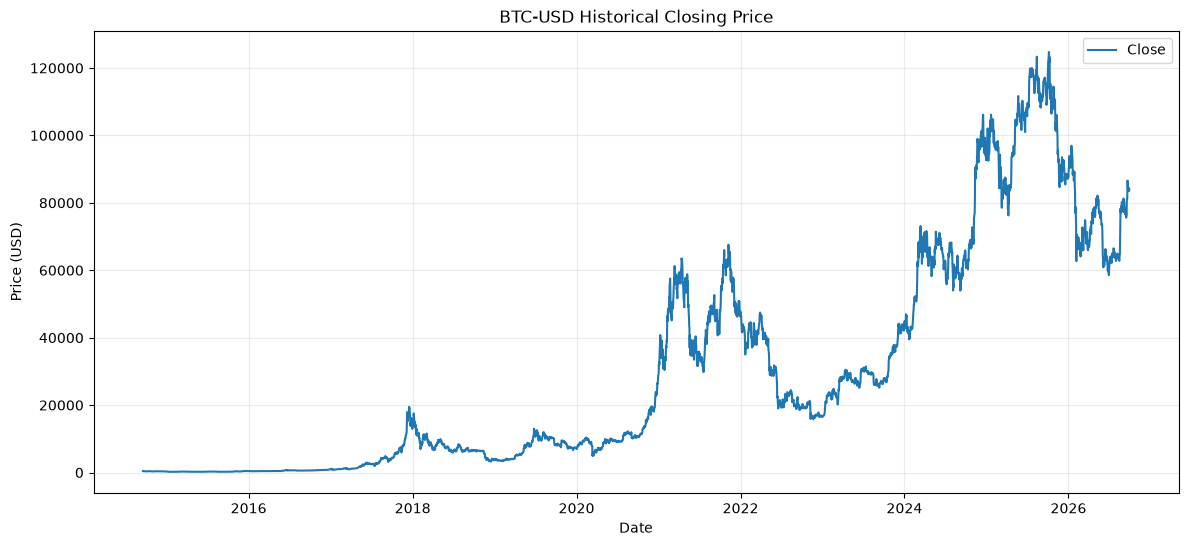

In [6]:
# Price history
plt.figure(figsize=(14, 6))
plt.plot(data.index, data["Close"], label="Close")
plt.title(f"{TICKER} Historical Closing Price")
plt.xlabel("Date")
plt.ylabel("Price (USD)")
plt.legend()
plt.grid(alpha=0.25)
plt.show()


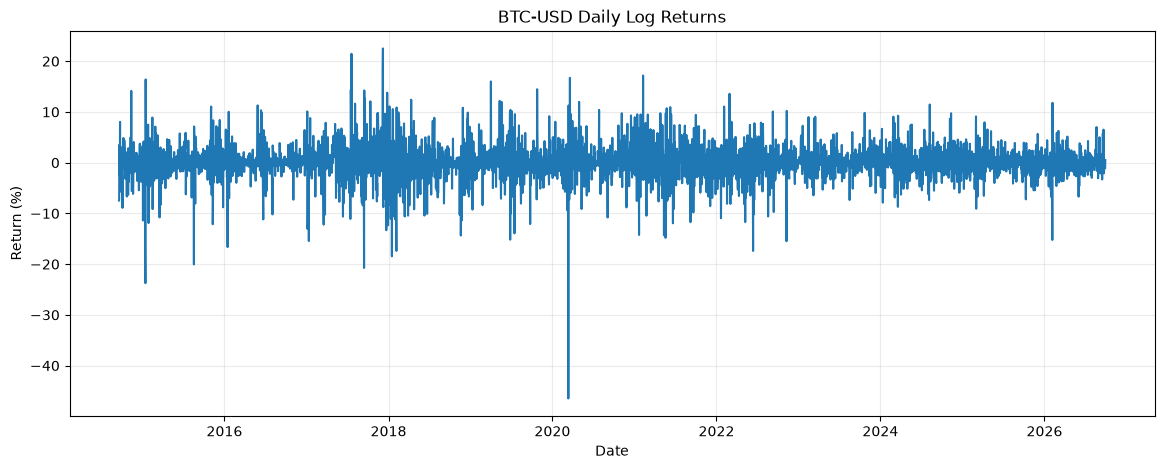

Annualized volatility estimate: 66.54 %


In [7]:
# Log returns
data["Return"] = np.log(data["Close"] / data["Close"].shift(1))
data["Daily_Return_%"] = data["Return"] * 100

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(data.index, data["Daily_Return_%"])
ax.set_title(f"{TICKER} Daily Log Returns")
ax.set_xlabel("Date")
ax.set_ylabel("Return (%)")
ax.grid(alpha=0.25)
plt.show()

print("Annualized volatility estimate:",
      round(data["Return"].std() * np.sqrt(365) * 100, 2), "%")


## 4. Feature Engineering

The machine-learning model uses lagged prices, returns, moving averages, volatility and RSI-like momentum information.

Using only past values avoids directly leaking future prices into the features.


In [8]:
df = data.copy()

# Lag features
for lag in [1, 2, 3, 7, 14, 30]:
    df[f"Close_Lag_{lag}"] = df["Close"].shift(lag)

# Moving averages
df["SMA_7"] = df["Close"].rolling(7).mean()
df["SMA_14"] = df["Close"].rolling(14).mean()
df["SMA_30"] = df["Close"].rolling(30).mean()
df["SMA_90"] = df["Close"].rolling(90).mean()

# Exponential moving averages
df["EMA_12"] = df["Close"].ewm(span=12, adjust=False).mean()
df["EMA_26"] = df["Close"].ewm(span=26, adjust=False).mean()

# MACD
df["MACD"] = df["EMA_12"] - df["EMA_26"]

# Rolling volatility
df["Volatility_7"] = df["Return"].rolling(7).std()
df["Volatility_30"] = df["Return"].rolling(30).std()

# RSI
delta = df["Close"].diff()
gain = delta.clip(lower=0)
loss = -delta.clip(upper=0)
avg_gain = gain.rolling(14).mean()
avg_loss = loss.rolling(14).mean()
rs = avg_gain / avg_loss.replace(0, np.nan)
df["RSI_14"] = 100 - (100 / (1 + rs))

df.dropna(inplace=True)

display(df.tail())


Price,Open,High,Low,Close,Volume,Return,Daily_Return_%,Close_Lag_1,Close_Lag_2,Close_Lag_3,...,SMA_7,SMA_14,SMA_30,SMA_90,EMA_12,EMA_26,MACD,Volatility_7,Volatility_30,RSI_14
Date,,,,,,,,,,,,,,,,,,,,,
2026-09-25,84379.515625,85230.054688,83165.531250,84034.921875,34118533914,-0.004087,-0.408685,84379.062500,84383.007812,86172.281250,...,83992.639509,80663.467634,79573.866406,70076.199913,82205.642443,79731.287831,2474.354612,0.027492,0.022587,68.905728
2026-09-26,84035.820312,84423.179688,83781.109375,84406.453125,15169336375,0.004411,0.441141,84034.921875,84379.062500,84383.007812,...,84445.892857,81173.180804,79712.163542,70352.578950,82544.228702,80077.596371,2466.632331,0.027490,0.022450,69.369698
2026-09-27,84412.718750,85126.109375,84121.328125,84458.085938,19386591468,0.000612,0.061153,84406.453125,84034.921875,84379.062500,...,84919.532366,81717.461496,79933.090104,70622.797917,82838.668277,80402.077080,2436.591197,0.027428,0.021605,71.119768
2026-09-28,84454.117188,84972.664062,82570.718750,83502.609375,42589028679,-0.011378,-1.137751,84458.085938,84406.453125,84034.921875,...,84476.631696,82098.834821,80108.316667,70899.950694,82940.813061,80631.746139,2309.066922,0.008576,0.021750,65.108121
2026-09-29,83488.000000,84457.812500,82800.398438,83909.296875,30999152640,0.004859,0.485853,83502.609375,84458.085938,84406.453125,...,84153.348214,82691.462612,80316.374219,71165.567795,83089.810571,80874.527675,2215.282896,0.009387,0.021679,76.719245


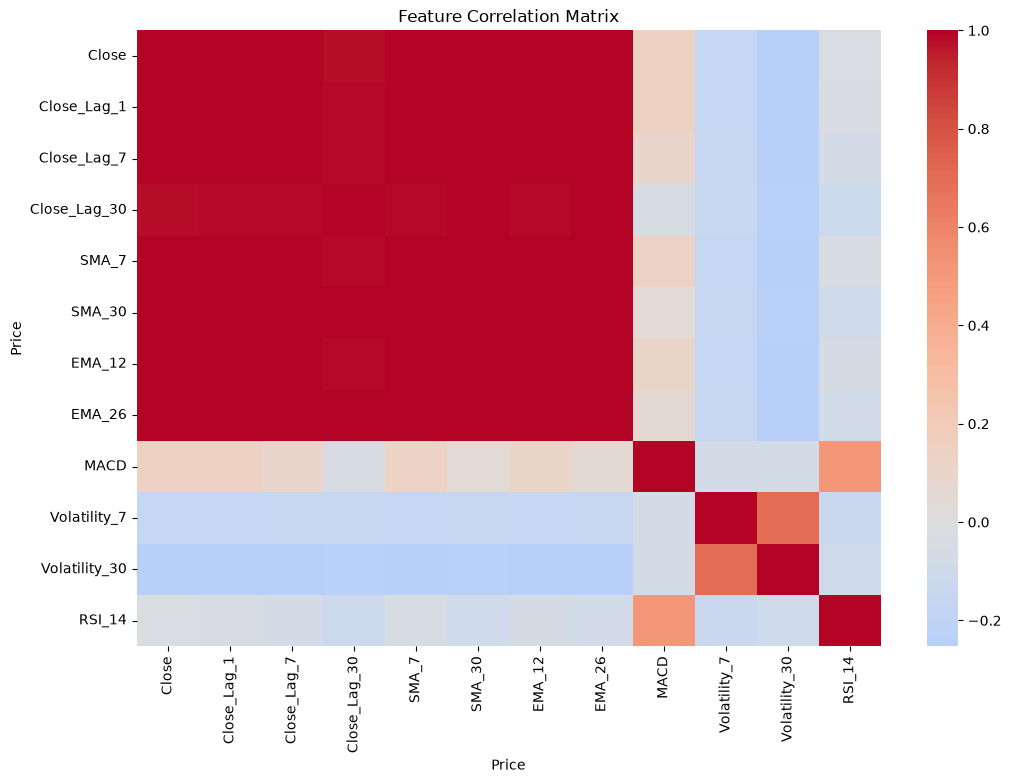

In [9]:
# Correlation with closing price
feature_cols = [
    "Close", "Close_Lag_1", "Close_Lag_7", "Close_Lag_30",
    "SMA_7", "SMA_30", "EMA_12", "EMA_26",
    "MACD", "Volatility_7", "Volatility_30", "RSI_14"
]

plt.figure(figsize=(12, 8))
sns.heatmap(df[feature_cols].corr(), cmap="coolwarm", center=0)
plt.title("Feature Correlation Matrix")
plt.show()


## 5. Train/Test Split

The split is chronological rather than random, which is important for time-series forecasting.


In [10]:
series = df["Close"].copy()

train = series.iloc[:-TEST_SIZE]
test = series.iloc[-TEST_SIZE:]

print("Training observations:", len(train))
print("Testing observations:", len(test))
print("Test period:", test.index.min().date(), "to", test.index.max().date())


Training observations: 4247
Testing observations: 60
Test period: 2026-08-01 to 2026-09-29


## 6. Evaluation Metrics

In [11]:
def evaluate(y_true, y_pred, name):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    return {
        "Model": name,
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "MAPE (%)": mean_absolute_percentage_error(y_true, y_pred) * 100
    }

results = []


## 7. Naive Baseline

In [12]:
# Predict every test day using the previous observed price
naive_pred = series.shift(1).iloc[-TEST_SIZE:]

naive_result = evaluate(test, naive_pred, "Naive")
results.append(naive_result)

print(naive_result)


{'Model': 'Naive', 'MAE': 1032.4600911458333, 'RMSE': np.float64(1686.0189222575711), 'MAPE (%)': 1.3483193905565034}


## 8. ARIMA

ARIMA is a classical statistical time-series model. Here we use a simple `(5,1,0)` configuration as a transparent baseline.


In [13]:
arima_model = ARIMA(train, order=(5, 1, 0))
arima_fit = arima_model.fit()

arima_pred = arima_fit.forecast(steps=len(test))
arima_pred.index = test.index

arima_result = evaluate(test, arima_pred, "ARIMA(5,1,0)")
results.append(arima_result)

print(arima_result)


C:\Users\BIKRAM SINGH\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
C:\Users\BIKRAM SINGH\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
C:\Users\BIKRAM SINGH\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


{'Model': 'ARIMA(5,1,0)', 'MAE': 11909.993544426768, 'RMSE': np.float64(14181.771468765373), 'MAPE (%)': 14.981611869265485}


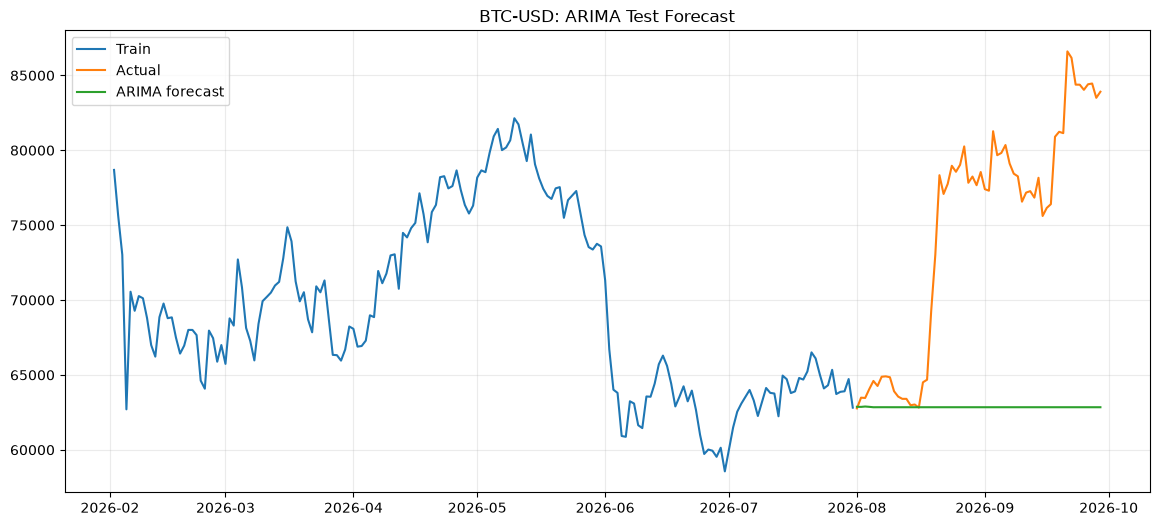

In [14]:
plt.figure(figsize=(14, 6))
plt.plot(train.index[-180:], train.iloc[-180:], label="Train")
plt.plot(test.index, test, label="Actual")
plt.plot(test.index, arima_pred, label="ARIMA forecast")
plt.title(f"{TICKER}: ARIMA Test Forecast")
plt.legend()
plt.grid(alpha=0.25)
plt.show()


## 9. Prophet

Prophet models trend and seasonality using a date-based formulation.


In [15]:
prophet_train = train.reset_index()
prophet_train.columns = ["ds", "y"]

prophet_model = Prophet(
    daily_seasonality=False,
    weekly_seasonality=True,
    yearly_seasonality=True
)

prophet_model.fit(prophet_train)

future_test = pd.DataFrame({"ds": test.index})
prophet_forecast = prophet_model.predict(future_test)
prophet_pred = pd.Series(
    prophet_forecast["yhat"].values,
    index=test.index
)

prophet_result = evaluate(test, prophet_pred, "Prophet")
results.append(prophet_result)

print(prophet_result)


19:49:14 - cmdstanpy - INFO - Chain [1] start processing
19:49:15 - cmdstanpy - INFO - Chain [1] done processing


{'Model': 'Prophet', 'MAE': 20664.931433189657, 'RMSE': np.float64(22071.485239748297), 'MAPE (%)': 29.097495009999818}


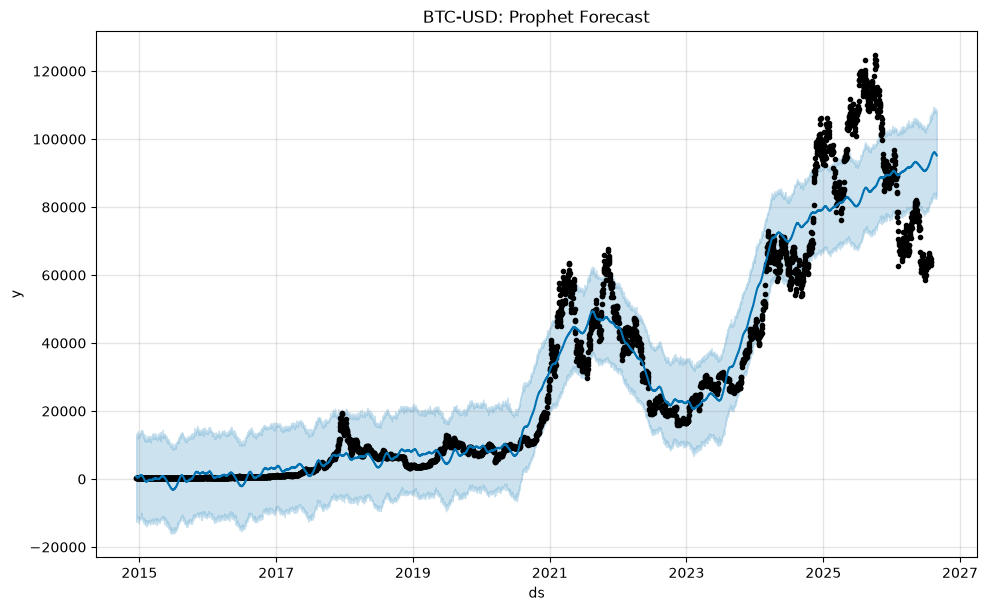

In [16]:
fig = prophet_model.plot(prophet_model.predict(
    prophet_model.make_future_dataframe(periods=FORECAST_DAYS)
))
plt.title(f"{TICKER}: Prophet Forecast")
plt.show()


## 10. Random Forest Regression

The Random Forest model learns nonlinear relationships between lagged prices and technical indicators.


In [17]:
rf_features = [
    "Close_Lag_1", "Close_Lag_2", "Close_Lag_3",
    "Close_Lag_7", "Close_Lag_14", "Close_Lag_30",
    "SMA_7", "SMA_14", "SMA_30", "SMA_90",
    "EMA_12", "EMA_26", "MACD",
    "Volatility_7", "Volatility_30", "RSI_14"
]

rf_df = df[rf_features + ["Close"]].dropna()

rf_train = rf_df.iloc[:-TEST_SIZE]
rf_test = rf_df.iloc[-TEST_SIZE:]

rf = RandomForestRegressor(
    n_estimators=400,
    max_depth=12,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

rf.fit(rf_train[rf_features], rf_train["Close"])
rf_pred = rf.predict(rf_test[rf_features])

rf_result = evaluate(rf_test["Close"], rf_pred, "Random Forest")
results.append(rf_result)

print(rf_result)


{'Model': 'Random Forest', 'MAE': 1293.5048360239118, 'RMSE': np.float64(1880.4853240197137), 'MAPE (%)': 1.6917065374845865}


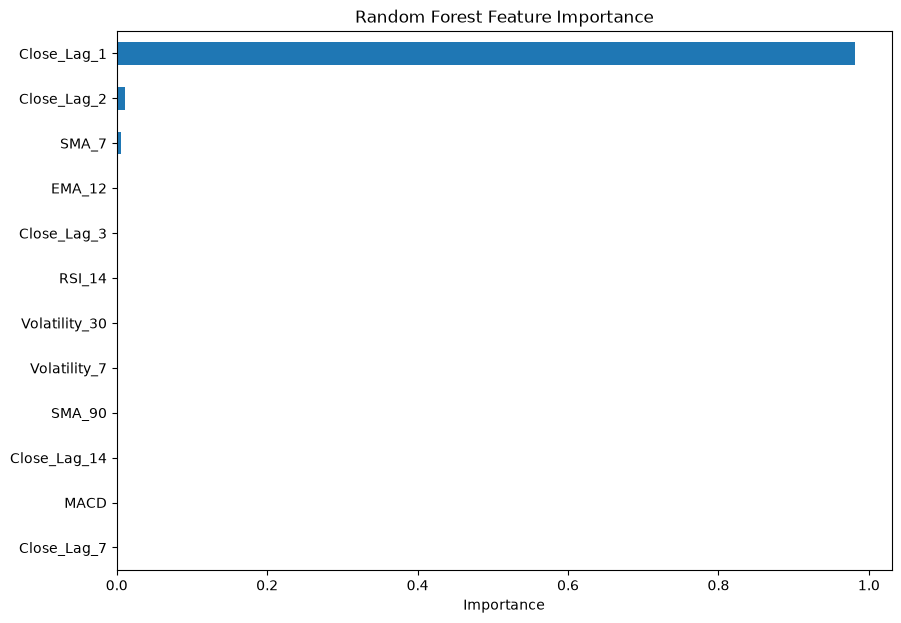

In [18]:
# Feature importance
importance = pd.Series(
    rf.feature_importances_,
    index=rf_features
).sort_values(ascending=False)

plt.figure(figsize=(10, 7))
importance.head(12).sort_values().plot(kind="barh")
plt.title("Random Forest Feature Importance")
plt.xlabel("Importance")
plt.show()


## 11. LSTM Neural Network

LSTM is trained on normalized historical closing prices using rolling sequences.

For reproducibility, the model uses a fixed random seed.


In [19]:
# Prepare LSTM data
close_values = series.values.reshape(-1, 1)

split_idx = len(close_values) - TEST_SIZE

scaler = MinMaxScaler()
train_scaled = scaler.fit_transform(close_values[:split_idx])

# Include the preceding LOOKBACK observations for test sequences
combined_scaled = scaler.transform(close_values)

X_train, y_train = [], []

for i in range(LOOKBACK, split_idx):
    X_train.append(combined_scaled[i-LOOKBACK:i, 0])
    y_train.append(combined_scaled[i, 0])

X_test, y_test = [], []

for i in range(split_idx, len(combined_scaled)):
    X_test.append(combined_scaled[i-LOOKBACK:i, 0])
    y_test.append(combined_scaled[i, 0])

X_train = np.array(X_train).reshape(-1, LOOKBACK, 1)
y_train = np.array(y_train)

X_test = np.array(X_test).reshape(-1, LOOKBACK, 1)
y_test = np.array(y_test)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)


X_train: (4187, 60, 1)
X_test: (60, 60, 1)


In [20]:
tf.random.set_seed(42)
np.random.seed(42)

lstm = Sequential([
    LSTM(64, return_sequences=True, input_shape=(LOOKBACK, 1)),
    Dropout(0.2),
    LSTM(32),
    Dropout(0.2),
    Dense(16, activation="relu"),
    Dense(1)
])

lstm.compile(
    optimizer="adam",
    loss="mse"
)

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=8,
    restore_best_weights=True
)

history = lstm.fit(
    X_train,
    y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.1,
    callbacks=[early_stop],
    verbose=1
)


Epoch 1/50
118/118 ━━━━━━━━━━━━━━━━━━━━ 6s 30ms/step - loss: 0.0047 - val_loss: 0.0027
Epoch 2/50
118/118 ━━━━━━━━━━━━━━━━━━━━ 3s 26ms/step - loss: 0.0014 - val_loss: 0.0012
Epoch 3/50
118/118 ━━━━━━━━━━━━━━━━━━━━ 3s 26ms/step - loss: 0.0010 - val_loss: 0.0012
Epoch 4/50
118/118 ━━━━━━━━━━━━━━━━━━━━ 3s 26ms/step - loss: 9.3297e-04 - val_loss: 0.0017
Epoch 5/50
118/118 ━━━━━━━━━━━━━━━━━━━━ 3s 26ms/step - loss: 9.6411e-04 - val_loss: 0.0013
Epoch 6/50
118/118 ━━━━━━━━━━━━━━━━━━━━ 3s 26ms/step - loss: 8.3037e-04 - val_loss: 8.9021e-04
Epoch 7/50
118/118 ━━━━━━━━━━━━━━━━━━━━ 3s 27ms/step - loss: 7.7097e-04 - val_loss: 9.2410e-04
Epoch 8/50
118/118 ━━━━━━━━━━━━━━━━━━━━ 3s 26ms/step - loss: 6.8826e-04 - val_loss: 0.0018
Epoch 9/50
118/118 ━━━━━━━━━━━━━━━━━━━━ 3s 26ms/step - loss: 7.0467e-04 - val_loss: 8.2902e-04
Epoch 10/50
118/118 ━━━━━━━━━━━━━━━━━━━━ 3s 26ms/step - loss: 5.9170e-04 - val_loss: 0.0034
Epoch 11/50
118/118 ━━━━━━━━━━━━━━━━━━━━ 3s 28ms/step - loss: 6.7992e-04 - val_loss: 0.00

{'Model': 'LSTM', 'MAE': 2444.0419921875, 'RMSE': np.float64(3843.4670193606603), 'MAPE (%)': 3.15950029320832}


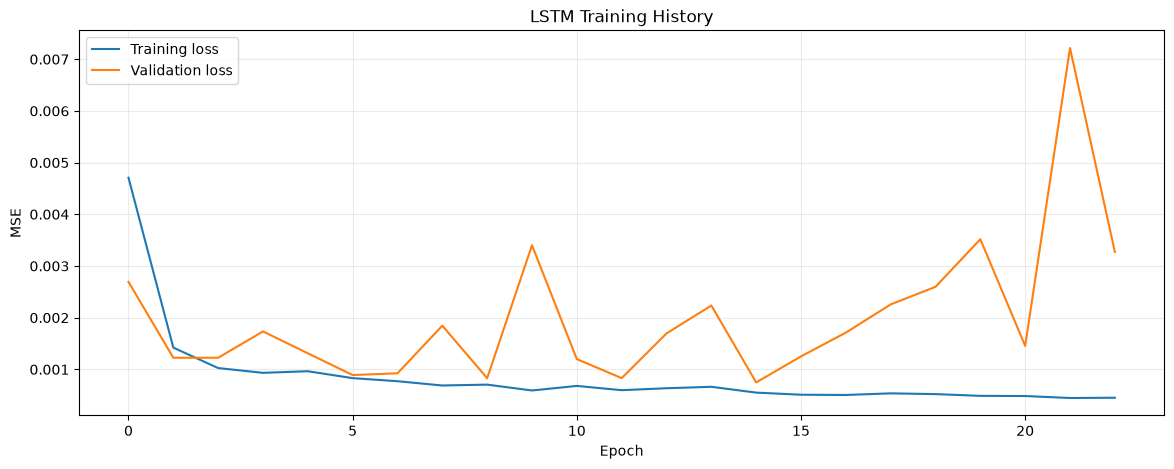

In [21]:
# LSTM test predictions
lstm_scaled_pred = lstm.predict(X_test, verbose=0)
lstm_pred = scaler.inverse_transform(lstm_scaled_pred).ravel()

lstm_result = evaluate(test.iloc[:len(lstm_pred)], lstm_pred, "LSTM")
results.append(lstm_result)

print(lstm_result)

plt.figure(figsize=(14, 5))
plt.plot(history.history["loss"], label="Training loss")
plt.plot(history.history["val_loss"], label="Validation loss")
plt.title("LSTM Training History")
plt.xlabel("Epoch")
plt.ylabel("MSE")
plt.legend()
plt.grid(alpha=0.25)
plt.show()


## 12. Model Comparison

,Model,MAE,RMSE,MAPE (%)
0,Naive,1032.460091,1686.018922,1.348319
1,Random Forest,1293.504836,1880.485324,1.691707
2,LSTM,2444.041992,3843.467019,3.159500
3,"ARIMA(5,1,0)",11909.993544,14181.771469,14.981612
4,Prophet,20664.931433,22071.485240,29.097495


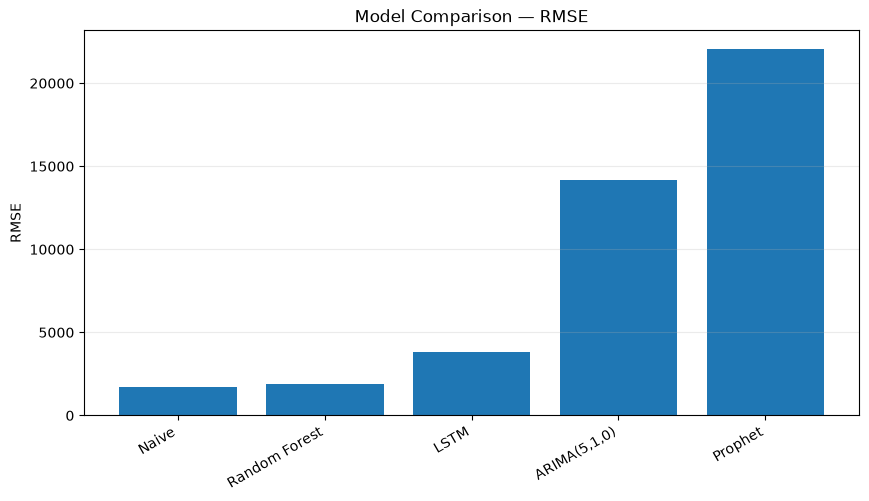

In [22]:
results_df = pd.DataFrame(results).sort_values("RMSE").reset_index(drop=True)
display(results_df)

plt.figure(figsize=(10, 5))
plt.bar(results_df["Model"], results_df["RMSE"])
plt.title("Model Comparison — RMSE")
plt.ylabel("RMSE")
plt.xticks(rotation=30, ha="right")
plt.grid(axis="y", alpha=0.25)
plt.show()


## 13. Final Test-Period Comparison

This plot compares predictions against actual prices on the held-out test period.


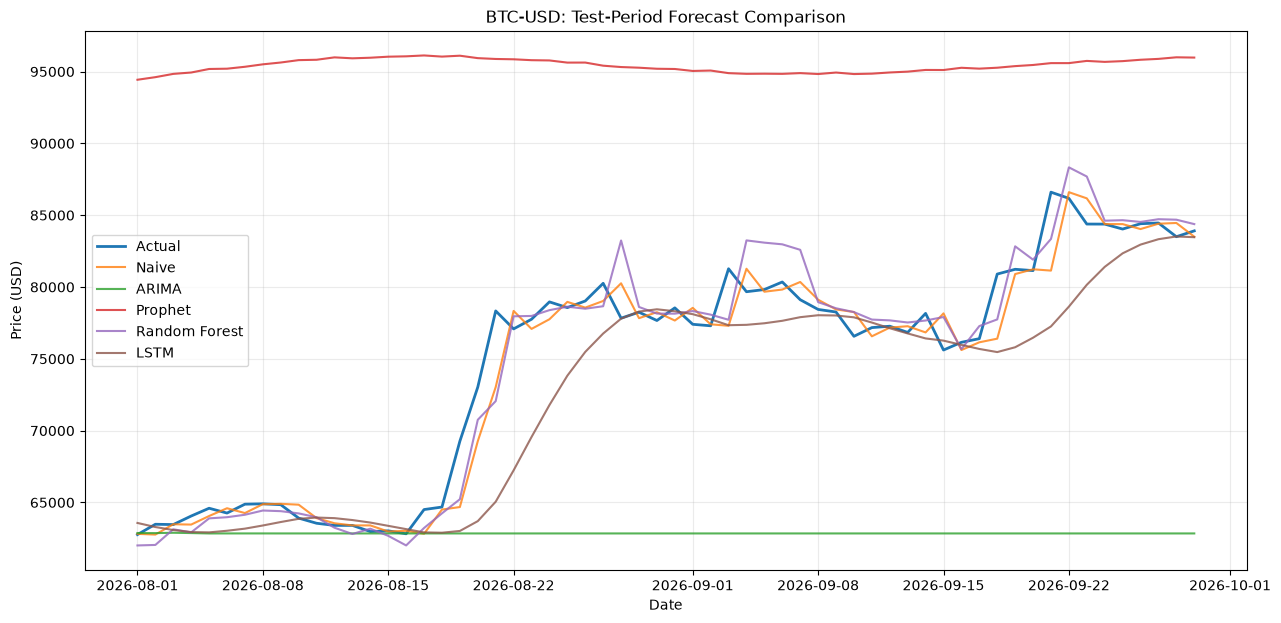

In [23]:
plt.figure(figsize=(15, 7))

plt.plot(test.index, test.values, label="Actual", linewidth=2)
plt.plot(test.index, naive_pred.values, label="Naive", alpha=0.8)
plt.plot(test.index, arima_pred.values, label="ARIMA", alpha=0.8)
plt.plot(test.index, prophet_pred.values, label="Prophet", alpha=0.8)
plt.plot(test.index, rf_pred, label="Random Forest", alpha=0.8)
plt.plot(test.index, lstm_pred, label="LSTM", alpha=0.8)

plt.title(f"{TICKER}: Test-Period Forecast Comparison")
plt.xlabel("Date")
plt.ylabel("Price (USD)")
plt.legend()
plt.grid(alpha=0.25)
plt.show()


## 14. Future Forecast

For the final forward forecast, the notebook uses **LSTM recursively** for the selected number of days.

Because recursive forecasting feeds predictions back into the model, uncertainty increases as the horizon gets longer.


In [24]:
# Retrain LSTM on all available data
all_scaler = MinMaxScaler()
all_scaled = all_scaler.fit_transform(series.values.reshape(-1, 1))

X_all, y_all = [], []

for i in range(LOOKBACK, len(all_scaled)):
    X_all.append(all_scaled[i-LOOKBACK:i, 0])
    y_all.append(all_scaled[i, 0])

X_all = np.array(X_all).reshape(-1, LOOKBACK, 1)
y_all = np.array(y_all)

final_lstm = Sequential([
    LSTM(64, return_sequences=True, input_shape=(LOOKBACK, 1)),
    Dropout(0.2),
    LSTM(32),
    Dropout(0.2),
    Dense(16, activation="relu"),
    Dense(1)
])

final_lstm.compile(optimizer="adam", loss="mse")

final_lstm.fit(
    X_all,
    y_all,
    epochs=30,
    batch_size=32,
    validation_split=0.1,
    callbacks=[EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True)],
    verbose=1
)


Epoch 1/30
120/120 ━━━━━━━━━━━━━━━━━━━━ 6s 28ms/step - loss: 0.0053 - val_loss: 0.0084
Epoch 2/30
120/120 ━━━━━━━━━━━━━━━━━━━━ 3s 27ms/step - loss: 0.0014 - val_loss: 0.0015
Epoch 3/30
120/120 ━━━━━━━━━━━━━━━━━━━━ 3s 26ms/step - loss: 0.0010 - val_loss: 0.0013
Epoch 4/30
120/120 ━━━━━━━━━━━━━━━━━━━━ 3s 27ms/step - loss: 0.0010 - val_loss: 0.0017
Epoch 5/30
120/120 ━━━━━━━━━━━━━━━━━━━━ 3s 26ms/step - loss: 9.7435e-04 - val_loss: 0.0010
Epoch 6/30
120/120 ━━━━━━━━━━━━━━━━━━━━ 3s 26ms/step - loss: 9.3816e-04 - val_loss: 0.0010
Epoch 7/30
120/120 ━━━━━━━━━━━━━━━━━━━━ 3s 26ms/step - loss: 8.4747e-04 - val_loss: 0.0037
Epoch 8/30
120/120 ━━━━━━━━━━━━━━━━━━━━ 3s 26ms/step - loss: 7.4522e-04 - val_loss: 9.5792e-04
Epoch 9/30
120/120 ━━━━━━━━━━━━━━━━━━━━ 3s 27ms/step - loss: 7.4854e-04 - val_loss: 0.0012
Epoch 10/30
120/120 ━━━━━━━━━━━━━━━━━━━━ 3s 27ms/step - loss: 7.7507e-04 - val_loss: 0.0013
Epoch 11/30
120/120 ━━━━━━━━━━━━━━━━━━━━ 3s 26ms/step - loss: 6.6244e-04 - val_loss: 8.0248e-04
Epoch

In [25]:
# Recursive future forecast
window = all_scaled[-LOOKBACK:].flatten().tolist()
future_scaled = []

for _ in range(FORECAST_DAYS):
    x = np.array(window[-LOOKBACK:]).reshape(1, LOOKBACK, 1)
    next_value = final_lstm.predict(x, verbose=0)[0, 0]
    future_scaled.append(next_value)
    window.append(next_value)

future_prices = all_scaler.inverse_transform(
    np.array(future_scaled).reshape(-1, 1)
).ravel()

last_date = series.index[-1]
future_dates = pd.date_range(
    last_date + pd.Timedelta(days=1),
    periods=FORECAST_DAYS,
    freq="D"
)

future_forecast = pd.DataFrame({
    "Date": future_dates,
    "Forecast": future_prices
}).set_index("Date")

display(future_forecast)


,Forecast
Date,
2026-09-30,83667.117188
2026-10-01,83661.968750
2026-10-02,83590.820312
2026-10-03,83476.687500
2026-10-04,83334.718750
2026-10-05,83174.718750
2026-10-06,83003.054688
2026-10-07,82823.742188
2026-10-08,82639.335938


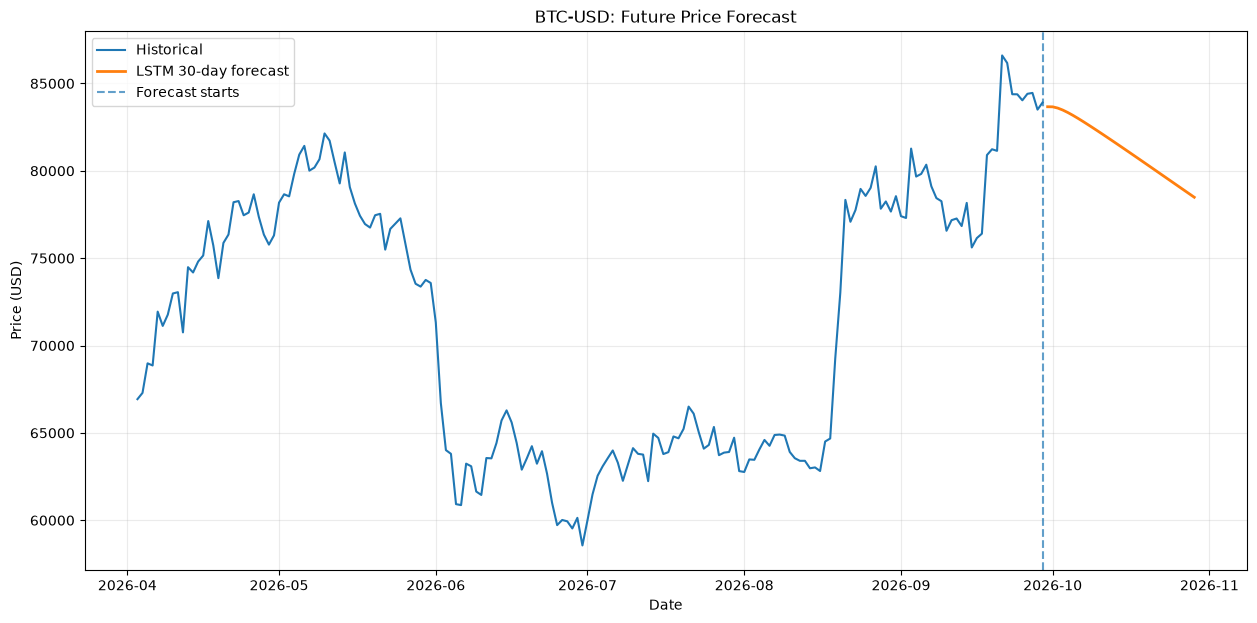

In [26]:
# Plot future forecast
history_window = series.iloc[-180:]

plt.figure(figsize=(15, 7))
plt.plot(history_window.index, history_window.values, label="Historical")
plt.plot(
    future_forecast.index,
    future_forecast["Forecast"],
    label=f"LSTM {FORECAST_DAYS}-day forecast",
    linewidth=2
)

plt.axvline(
    series.index[-1],
    linestyle="--",
    alpha=0.7,
    label="Forecast starts"
)

plt.title(f"{TICKER}: Future Price Forecast")
plt.xlabel("Date")
plt.ylabel("Price (USD)")
plt.legend()
plt.grid(alpha=0.25)
plt.show()


## 15. Forecast Summary

The following cell prints the latest observed price and the model's projected endpoint.

**Do not interpret the forecast as a guaranteed future price.** Crypto prices can be affected by market structure, macroeconomic conditions, regulation, liquidity, news and other variables that are not represented by this univariate model.


In [27]:
latest_price = float(series.iloc[-1])
forecast_end = float(future_forecast["Forecast"].iloc[-1])
forecast_change = (forecast_end / latest_price - 1) * 100

print(f"Asset: {TICKER}")
print(f"Latest observed close: ${latest_price:,.2f}")
print(f"Forecast horizon: {FORECAST_DAYS} days")
print(f"Forecast endpoint: ${forecast_end:,.2f}")
print(f"Model-implied change over horizon: {forecast_change:+.2f}%")
print()
print("This is a statistical forecast, not financial advice.")


Asset: BTC-USD
Latest observed close: $83,909.30
Forecast horizon: 30 days
Forecast endpoint: $78,486.85
Model-implied change over horizon: -6.46%

This is a statistical forecast, not financial advice.


## 16. Optional: Change the Cryptocurrency

Set the ticker at the top and **Run All** again.

Examples:

```python
TICKER = "ETH-USD"
```

```python
TICKER = "SOL-USD"
```

```python
TICKER = "BNB-USD"
```

The notebook will fetch fresh data for the selected asset when it executes.
